# Importing Important Libraries

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection  import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import re
import nltk

nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\pulki/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Major Operations:
1. Importing dataset as pandas DataFrame

In [2]:
df= pd.read_csv(r"C:\Users\pulki\PolariSense- IMDB Sentiment Intelligence\data\IMDB Dataset.csv")

Printing top 5 keys of the dataset

In [3]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


2. Data Info

In [4]:
df.shape

(50000, 2)

In [5]:
df.describe

<bound method NDFrame.describe of                                                   review sentiment
0      One of the other reviewers has mentioned that ...  positive
1      A wonderful little production. <br /><br />The...  positive
2      I thought this was a wonderful way to spend ti...  positive
3      Basically there's a family where a little boy ...  negative
4      Petter Mattei's "Love in the Time of Money" is...  positive
...                                                  ...       ...
49995  I thought this movie did a down right good job...  positive
49996  Bad plot, bad dialogue, bad acting, idiotic di...  negative
49997  I am a Catholic taught in parochial elementary...  negative
49998  I'm going to have to disagree with the previou...  negative
49999  No one expects the Star Trek movies to be high...  negative

[50000 rows x 2 columns]>

In [6]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

No null value is present in our dataset

3. Basic EDA Operation

In [7]:
df['sentiment'].value_counts

<bound method IndexOpsMixin.value_counts of 0        positive
1        positive
2        positive
3        negative
4        positive
           ...   
49995    positive
49996    negative
49997    negative
49998    negative
49999    negative
Name: sentiment, Length: 50000, dtype: object>

Making plot of Sentiments' features

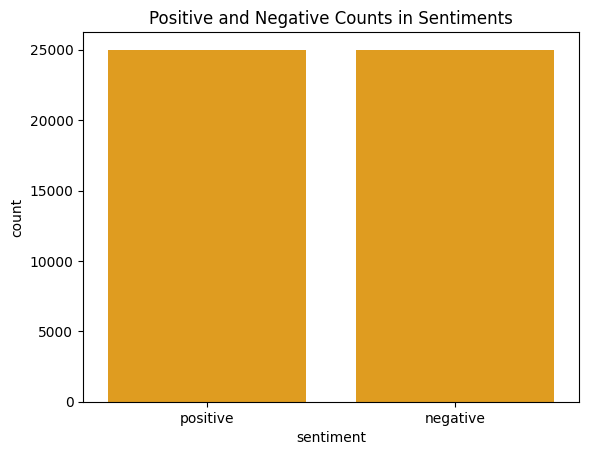

In [8]:
sns.countplot(x= 'sentiment', data= df, color= 'orange')
plt.title('Positive and Negative Counts in Sentiments')
plt.show()

In [9]:
df['review_length']= df['review'].apply(len)

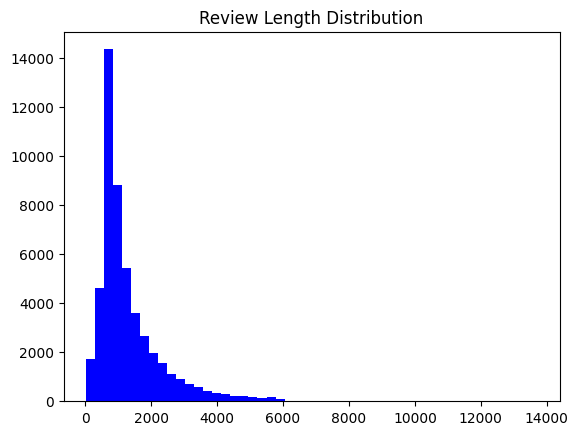

In [10]:
plt.hist(df['review_length'], bins= 50, color= 'blue')
plt.title('Review Length Distribution')
plt.show()

4. Text Cleaning

In [11]:
stop_words= set(stopwords.words('english'))

def clean_text(text):
    text = str(text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = text.lower()
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [12]:
df['cleaned_review']= df['review'].apply(clean_text)

5. Converting Labels into numbers

In [13]:
df['sentiment']= df['sentiment'].map({'positive': 1, 'negative': 0})
y= df['sentiment']
y

0        1
1        1
2        1
3        0
4        1
        ..
49995    1
49996    0
49997    0
49998    0
49999    0
Name: sentiment, Length: 50000, dtype: int64

6. Train-Test of the model

In [14]:
X= df['cleaned_review']
y= df['sentiment']

In [15]:
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size= 0.2, random_state= 12)

In [16]:
tfidf= TfidfVectorizer(max_features= 5000, ngram_range= (1,2))

X_train_tfidf= tfidf.fit_transform(X_train)
X_test_tfidf= tfidf.transform(X_test)

In [17]:
model= LogisticRegression(max_iter= 1000)
model.fit(X_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [18]:
y_pred= model.predict(X_test_tfidf)

Accuracy Score 0.8929

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.88      0.89      5017
           1       0.89      0.90      0.89      4983

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



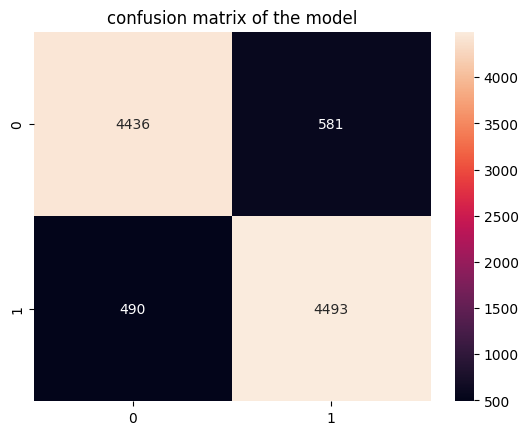

In [19]:
accuracy_tfidf= accuracy_score(y_test, y_pred)
print("Accuracy Score", accuracy_tfidf)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

cm= confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot= True, fmt= 'd')
plt.title("confusion matrix of the model")
plt.show()

In [20]:
def predict_review(review):
    review_clean= clean_text(review)
    review_vector= tfidf.transform([review_clean])
    prediction= model.predict(review_vector)[0]

    if prediction== 1:
        return 'postive 😊'
    else:
        return 'negative 😞'

In [21]:
print(predict_review("This movie was absolutely fantastic!"))

postive 😊


7. Importing other important libraries

In [22]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

Performing Tokenization

In [23]:
max_words= 10000

tokenizer= Tokenizer(num_words= max_words)
tokenizer.fit_on_texts(df['cleaned_review'])

sequences= tokenizer.texts_to_sequences(df['cleaned_review'])

Performing Padding

In [24]:
max_len= 200
X_padded= pad_sequences(sequences, maxlen= max_len)

y= df['sentiment']

In [25]:
X_train, X_test, y_train, y_test= train_test_split(X_padded, y, test_size= 0.2, random_state= 12)

# Training LSTM

In [26]:
model_lstm= Sequential()

model_lstm.add(Embedding(max_words, 128, input_length= max_len))
model_lstm.add(LSTM(128, return_sequences= False))
model_lstm.add(Dropout(0.5))
model_lstm.add(Dense(1, activation= 'sigmoid'))

model_lstm.compile(
    loss= 'binary_crossentropy',
    optimizer= 'adam',
    metrics= ['accuracy']
)

model_lstm.summary()

C:\Users\pulki\miniconda3\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [27]:
history_lstm= model_lstm.fit(
    X_train,
    y_train,
    epochs= 5,
    batch_size= 64,
    validation_split= 0.2
)

Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 315s 612ms/step - accuracy: 0.7946 - loss: 0.4339 - val_accuracy: 0.8474 - val_loss: 0.3584
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 275s 550ms/step - accuracy: 0.8976 - loss: 0.2631 - val_accuracy: 0.8695 - val_loss: 0.3162
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 331s 662ms/step - accuracy: 0.9225 - loss: 0.2037 - val_accuracy: 0.8630 - val_loss: 0.3427
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 370s 739ms/step - accuracy: 0.9468 - loss: 0.1495 - val_accuracy: 0.8767 - val_loss: 0.3917
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 377s 754ms/step - accuracy: 0.9577 - loss: 0.1217 - val_accuracy: 0.8665 - val_loss: 0.3865


In [28]:
loss, accuracy= model_lstm.evaluate(X_test, y_test)
print("LSTM Test Accuracy: ", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 29s 89ms/step - accuracy: 0.8640 - loss: 0.3744
LSTM Test Accuracy:  0.8640000224113464


Plot Accuracy and Loss

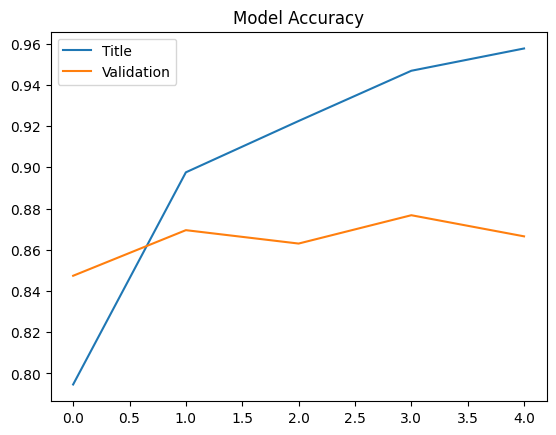

In [29]:
plt.plot(history_lstm.history['accuracy'])
plt.plot(history_lstm.history['val_accuracy'])
plt.title('Model Accuracy')
plt.legend(['Title', 'Validation'])
plt.show()

# Training Bidirectional LSTM

In [30]:
model_bilstm= Sequential()

model_bilstm.add(Embedding(max_words, 128, input_length= max_len))
model_bilstm.add(Bidirectional(LSTM(128)))
model_bilstm.add(Dropout(0.5))
model_bilstm.add(Dense(1, activation= 'sigmoid'))

model_bilstm.compile(
    loss=  'binary_crossentropy',
    optimizer=  'adam',
    metrics= ['accuracy']
)

model_bilstm.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [31]:
history_bilstm= model_bilstm.fit(
    X_train,
    y_train,
    epochs= 5,
    batch_size= 64,
    validation_split= 0.2
)

Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 753s 1s/step - accuracy: 0.8172 - loss: 0.4072 - val_accuracy: 0.8511 - val_loss: 0.3450
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 692s 1s/step - accuracy: 0.9016 - loss: 0.2594 - val_accuracy: 0.8683 - val_loss: 0.3213
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 603s 1s/step - accuracy: 0.9212 - loss: 0.2119 - val_accuracy: 0.8750 - val_loss: 0.3145
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 648s 1s/step - accuracy: 0.9424 - loss: 0.1597 - val_accuracy: 0.8670 - val_loss: 0.3749
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 612s 1s/step - accuracy: 0.9547 - loss: 0.1283 - val_accuracy: 0.8665 - val_loss: 0.4138


In [32]:
loss_bi, accuracy_bi= model_bilstm.evaluate(X_test, y_test)
print("BiLSTM Test Accuracy: ", accuracy_bi)

313/313 ━━━━━━━━━━━━━━━━━━━━ 62s 196ms/step - accuracy: 0.8677 - loss: 0.4007
BiLSTM Test Accuracy:  0.8676999807357788


Comparing Models

In [33]:
print("TF-IDF Vectorizer Accuracy", accuracy_tfidf)
print("LSTM Test Accuracy: ", accuracy)
print("BiLSTM Test Accuracy: ", accuracy_bi)

TF-IDF Vectorizer Accuracy 0.8929
LSTM Test Accuracy:  0.8640000224113464
BiLSTM Test Accuracy:  0.8676999807357788


In [34]:
def predict_sentiment(review):
    review= clean_text(review)
    seq= tokenizer.texts_to_sequences([review])
    padded = pad_sequences(seq, maxlen=max_len)
    prediction = model_bilstm.predict(padded)[0][0]

    if prediction> 0.5:
        return 'postive 😊'
    else:
        return 'negative 😞'

🔎 Conclusion

- In this project, we implemented and compared three different approaches for sentiment analysis on the IMDB 50K movie review dataset: TF-IDF with Logistic Regression, LSTM, and Bidirectional LSTM.

- The TF-IDF model achieved the highest accuracy of 89.29%, demonstrating that traditional machine learning models remain highly competitive for structured sentiment datasets.

- The LSTM model achieved 86.40%, while the Bidirectional LSTM slightly improved performance to 86.77%, showing the benefit of learning contextual information from both forward and backward sequences.

- A key insight from this project was the importance of proper preprocessing, especially maintaining whitespace and appropriate sequence length (max_len=200). Debugging preprocessing errors significantly improved model performance from 50% to above 86%.

- Overall, this project highlights:

1. The strength of classical ML baselines.

2. The importance of sequence length in deep learning.

3. The critical role of clean preprocessing in NLP pipelines